In [1]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
# Set styles and seeds for reproducibility
plt.style.use('seaborn-v0_8')
sns.set_palette(sns.color_palette())
np.random.seed(42)

In [3]:
def read_json_reports_into_list(file_names, directory="classification_report"):
    """
    Reads multiple JSON files, converts each report into a dictionary,
    and combines them into a list of dictionaries.
    
    Args:
        file_names (list): A list of file names (without the .json extension).
        directory (str): The directory where the JSON files are located.
        
    Returns:
        list: A list of dictionaries, where each dictionary is a model's report.
    """
    all_reports = []
    
    for name in file_names:
        file_path = os.path.join(directory, f"{name}.json")
        
        try:
            with open(file_path, 'r') as f:
                report = json.load(f)
            
            # Add the model name to the dictionary for identification later
            report['Model'] = name
            
            # Append the dictionary (JSON object) to the list
            all_reports.append(report)
            print(f"Successfully loaded report from: {name}.json")
            
        except FileNotFoundError:
            print(f"Error: File not found at {file_path}. Skipping this model.")
        except json.JSONDecodeError:
            print(f"Error: Could not decode JSON from {file_path}. Skipping this model.")
            
    return all_reports

In [4]:
model_files = {
    "lr_lab",
    "lr_scikit",
    "lr_lab_softmax",
    "nn_tuned",
    "nn",
    "dt"
}

# 2. Execute the function to read the files
reports_array = read_json_reports_into_list(model_files)

# 3. Print the resulting array and show how to convert it to a DataFrame
print("\n--- Resulting Array (List of Dictionaries) ---")
print(json.dumps(reports_array, indent=4)) # Use json.dumps for neat printing

Successfully loaded report from: lr_lab.json
Successfully loaded report from: lr_scikit.json
Successfully loaded report from: nn.json
Successfully loaded report from: dt.json
Successfully loaded report from: nn_tuned.json
Successfully loaded report from: lr_lab_softmax.json

--- Resulting Array (List of Dictionaries) ---
[
    {
        "accuracy": 0.8944790739091718,
        "precision": 0.8956179559785453,
        "recall": 0.8944790739091718,
        "f1-score": 0.8943708196524582,
        "Model": "lr_lab"
    },
    {
        "accuracy": 0.9154051647373108,
        "precision": 0.9169818514346552,
        "recall": 0.9154051647373108,
        "f1-score": 0.9157236953190044,
        "Model": "lr_scikit"
    },
    {
        "accuracy": 0.9247551202137133,
        "precision": 0.9268973678849176,
        "recall": 0.9247551202137133,
        "f1-score": 0.9251096908567822,
        "Model": "nn"
    },
    {
        "accuracy": 0.9020480854853072,
        "precision": 0.9032610263902

    accuracy  precision     recall   f1-score           Model
0  89.447907  89.561796  89.447907  89.437082          LR lab
1  91.540516  91.698185  91.540516  91.572370       LR scikit
2  92.475512  92.689737  92.475512  92.510969              NN
3  90.204809  90.326103  90.204809  90.226361              DT
4  92.831701  92.872278  92.831701  92.834337        NN Tuned
5  90.783615  90.969018  90.783615  90.821189  LR lab softmax
--- df_melted structure (Model names are preserved) ---
| Model          | Metric    |   Score |
|:---------------|:----------|--------:|
| LR lab         | accuracy  |   89.45 |
| LR scikit      | accuracy  |   91.54 |
| NN             | accuracy  |   92.48 |
| DT             | accuracy  |   90.20 |
| NN Tuned       | accuracy  |   92.83 |
| LR lab softmax | accuracy  |   90.78 |
| LR lab         | precision |   89.56 |
| LR scikit      | precision |   91.70 |


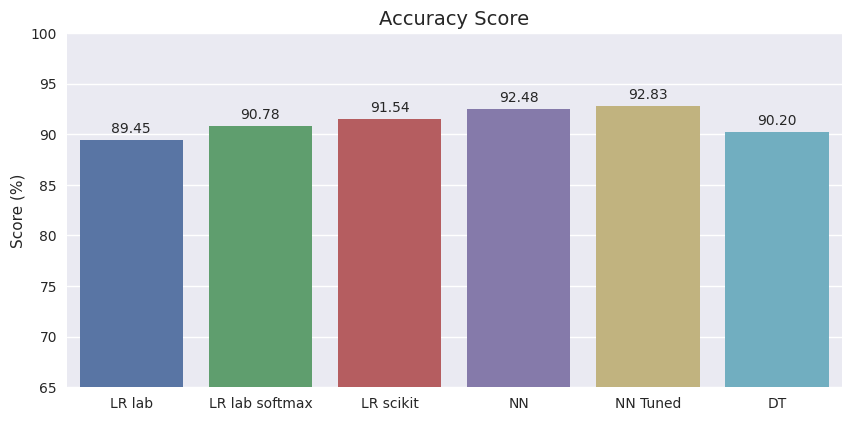

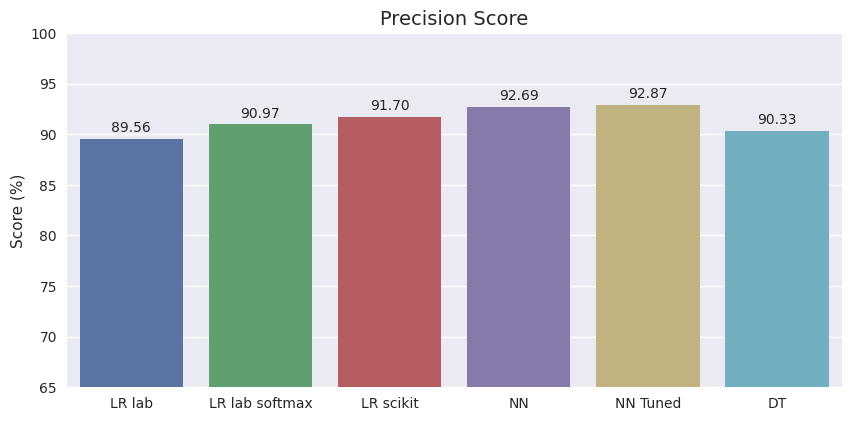

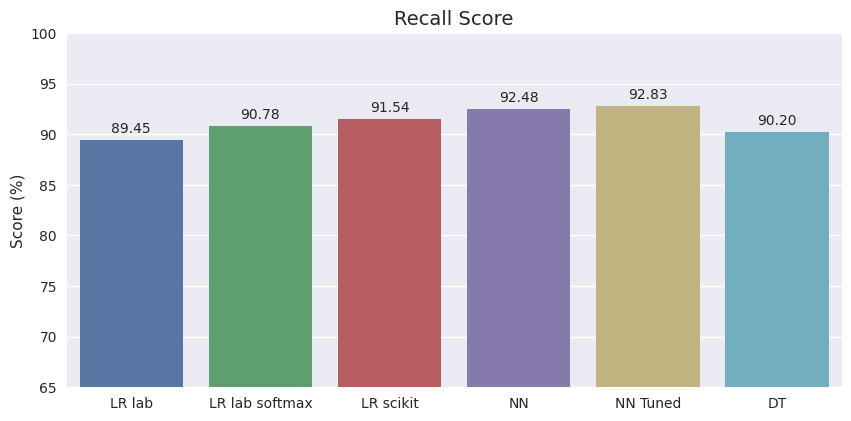

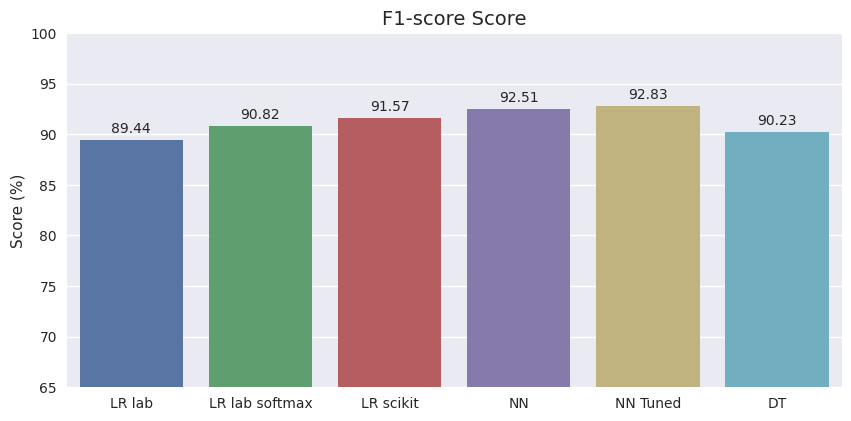

<Figure size 800x550 with 0 Axes>

In [5]:
# Bar plot order
label_order = ['LR lab', 'LR lab softmax', 'LR scikit', 'NN', 'NN Tuned', 'DT']

# Bar plot metrics
metrics = ["accuracy", "precision", "recall", "f1-score"]

# Convert to DataFrame for easier plotting
df = pd.DataFrame(reports_array) # Transpose so models are rows
df[metrics] *= 100
# Update model names
# IMPORTANT: Replace longer strings FIRST to avoid partial replacements
df['Model'] = df['Model'].str.replace('lr_lab_softmax', 'LR lab softmax')  # Must come before 'lr_lab'
df['Model'] = df['Model'].str.replace('lr_lab', 'LR lab')
df['Model'] = df['Model'].str.replace('lr_scikit', 'LR scikit')
df['Model'] = df['Model'].str.replace('nn_tuned', 'NN Tuned')
df['Model'] = df['Model'].str.replace('nn', 'NN')
df['Model'] = df['Model'].str.replace('dt', 'DT')

print(df)

# Melt the dataframe to make it suitable for seaborn barplots
df_melted = df.melt(id_vars="Model", var_name="Metric", value_name="Score")

print("--- df_melted structure (Model names are preserved) ---")
print(df_melted.head(8).to_markdown(index=False, floatfmt=".2f"))

for metric in metrics:
    # Filter data for the specific metric
    subset = df_melted[df_melted["Metric"] == metric]

    plt.figure(figsize=(10, 4.6))
    # Create Bar Plot
    ax = sns.barplot(
        data=subset, 
        x='Model', 
        y='Score', 
        hue='Model', 
        order=label_order,
        hue_order=label_order,
        dodge=False # Prevent clustering since we only have one value per model on the x-axis
    )
    
    # Formatting
    plt.title(f'{metric.capitalize()} Score', fontsize=14)
    plt.ylim(65, 100) # Score is usually 0-1
    plt.xlabel("")
    plt.ylabel("Score (%)")
    
    # Add text labels on bars
    for container in ax.containers:
        plt.bar_label(container, fmt='%.2f', padding=3)

    plt.show()

# Adjust layout to fit title
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()